# 10 — Target Variable Construction

Builds the **`target`** column for downstream territorial-control modelling on a
PRIO-GRID cell × month panel for Myanmar.

**Base**: full Wikipedia label panel (`data/processed/myanmar_priogrid_labels.csv`,
5,238 cell-months, 185 cells, Nov 2023 – Mar 2026).  
ACLED territorial-control signals (`checkpoints/09_acled_wiki_comparison.parquet`)
are left-joined onto that base to enrich rows that happen to have a control-signal event
in the same cell-month.  
For rows with no ACLED control event the Wikipedia label is used directly.

**Decision rules** (applied in order; first matching rule wins):

| # | Condition | target | reason |
|---|-----------|--------|--------|
| 0 | Wiki only — no ACLED control event | wiki_side (gov/opo) or uncertain (contested) | `wiki_only` |
| 1 | ACLED == Wiki (agree) | that side | `agree` |
| 2 | Wiki = contested, ACLED has clear side | ACLED side | `wiki_contested_use_acled` |
| 3 | ACLED ≠ Wiki, Wiki NOT changed within ±1 month | ACLED side | `disagree_stable_wiki_use_acled` |
| 4 | ACLED ≠ Wiki, Wiki DID change within ±1 month | Wiki side | `disagree_recent_wiki_use_wiki` |
| 5 | ACLED has control signals from both sides | `uncertain` | `acled_mixed` |

**Output**: `checkpoints/10_target_variable.parquet`

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import geopandas as gpd
from shapely.geometry import box
from pathlib import Path

NB_DIR = Path('.')
ROOT   = Path('../..')
FIG    = ROOT / 'reports' / 'figures'
CKPT   = Path('../checkpoints')
FIG.mkdir(parents=True, exist_ok=True)

COMP_PATH  = CKPT / '09_acled_wiki_comparison.parquet'
WIKI_PATH  = ROOT / 'data/processed/myanmar_priogrid_labels.csv'
GADM_PATH  = ROOT / 'data/raw/gadm/gadm41_MMR.gpkg'
CKPT_OUT   = CKPT / '10_target_variable.parquet'

MMR = (92.0, 9.5, 101.5, 28.5)

TARGET_COLORS = {
    'gov':       '#CC3333',
    'opo':       '#3399CC',
    'uncertain': '#AAAAAA',
}

REASON_COLORS = {
    'wiki_only':                      '#2196F3',
    'agree':                          '#4CAF50',
    'wiki_contested_use_acled':       '#8BC34A',
    'disagree_stable_wiki_use_acled': '#FF9800',
    'disagree_recent_wiki_use_wiki':  '#9C27B0',
    'acled_mixed':                    '#FF5722',
}

# wiki control_status → 3-value side used for comparison and target assignment
WIKI_SIDE_MAP = {
    'government':         'gov',
    'resistance':         'opo',
    'ethnic_armed_group': 'opo',
    'contested':          'contested',
}
# wiki_side → target (contested maps to uncertain when no ACLED clarifies)
WIKI_TO_TARGET = {'gov': 'gov', 'opo': 'opo', 'contested': 'uncertain'}

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)

def gid_to_geometry(gid):
    row = (gid - 1) // 720 + 1
    col = (gid - 1) % 720 + 1
    return box((col-1)*0.5-180, (row-1)*0.5-90,
               (col-1)*0.5-180+0.5, (row-1)*0.5-90+0.5)

print('Setup complete.')

Setup complete.


## 1. Load Wikipedia panel — base of the target frame

The full Wikipedia label panel (5,238 cell-months) is the base from which the target
variable is built. Every row already has a `control_status` label (LOCF-filled between
Wikipedia snapshots). We map it to a 3-value `wiki_side`:
`government → gov`, `resistance/ethnic_armed_group → opo`, `contested → contested`.

In [2]:
wiki = pd.read_csv(WIKI_PATH)
wiki = wiki.sort_values(['priogrid_gid', 'year_month']).reset_index(drop=True)
wiki['wiki_side'] = wiki['control_status'].map(WIKI_SIDE_MAP)

print(f'Wikipedia panel: {len(wiki):,} rows  |  {wiki["priogrid_gid"].nunique()} cells  |  '
      f'{wiki["year_month"].nunique()} months')
print(f'Date range: {wiki["year_month"].min()} → {wiki["year_month"].max()}')
print()
print('control_status distribution:')
for cs, n in wiki['control_status'].value_counts().items():
    side = WIKI_SIDE_MAP.get(cs, '?')
    print(f'  {cs:<22} {n:>5,}  → wiki_side = {side}')
print()
print('wiki_side distribution:')
print(wiki['wiki_side'].value_counts().to_string())

Wikipedia panel: 5,238 rows  |  185 cells  |  29 months
Date range: 2023-11 → 2026-03

control_status distribution:
  government             3,323  → wiki_side = gov
  contested                891  → wiki_side = contested
  ethnic_armed_group       613  → wiki_side = opo
  resistance               411  → wiki_side = opo

wiki_side distribution:
wiki_side
gov          3323
opo          1024
contested     891


## 2. Compute `wiki_changed_recent`

For each cell, flag month t as `True` if the Wikipedia label differs from t-1 or t+1.
This identifies label-transition windows — used in rules 3 and 4 to decide whether a
ACLED–Wiki disagreement reflects genuine uncertainty or a stale Wikipedia entry.

Boundary months (no predecessor / no successor for a given cell) default to `False`.

In [3]:
grp      = wiki.groupby('priogrid_gid')['control_status']
prev_diff = grp.shift(1).ne(wiki['control_status']).fillna(False)
next_diff = grp.shift(-1).ne(wiki['control_status']).fillna(False)
wiki['wiki_changed_recent'] = prev_diff | next_diff

print('wiki_changed_recent distribution:')
print(wiki['wiki_changed_recent'].value_counts().to_string())
pct = wiki['wiki_changed_recent'].mean() * 100
print(f'  → {pct:.1f}% of cell-month wiki labels sit within a transition window')

wiki_changed_recent distribution:
wiki_changed_recent
False    4673
True      565
  → 10.8% of cell-month wiki labels sit within a transition window


## 3. Load ACLED control-signal aggregates from checkpoint 09

We extract only the pre-aggregated ACLED columns (counts, side, admin1) and drop the old
`agreement` and `wiki_side` columns — those will be re-derived fresh from the wiki base.

In [4]:
comp = pd.read_parquet(COMP_PATH)

# Keep only the ACLED-side columns; drop the old agreement/wiki_side that were
# computed against the ACLED-first join in notebook 09
ACLED_COLS = ['priogrid_gid', 'year_month',
              'n_gov', 'n_opo', 'n_unmapped', 'total_ctrl_evs',
              'admin1', 'acled_side']
acled_agg = comp[ACLED_COLS].copy()

print(f'ACLED control-signal aggregates: {len(acled_agg):,} rows  |  '
      f'{acled_agg["priogrid_gid"].nunique()} unique cells')
print()
print('acled_side distribution:')
print(acled_agg['acled_side'].value_counts().to_string())

ACLED control-signal aggregates: 336 rows  |  127 unique cells

acled_side distribution:
acled_side
opo              233
gov               91
mixed              6
unmapped_only      6


## 4. Left-join wiki ← ACLED; derive agreement

Starting from the full wiki panel (5,238 rows), we left-join the ACLED aggregates.
Rows with no ACLED match get `acled_side = 'none'` and `agreement = 'wiki_only'`.

Agreement is derived fresh (not inherited from comp) using the wiki_side from this panel:

| acled_side | wiki_side | agreement |
|------------|-----------|-----------|
| none | any | wiki_only |
| mixed | any | acled_mixed |
| unmapped_only | any | wiki_only (no ACLED side info) |
| gov/opo | contested | wiki_contested |
| gov/opo | same as acled | agree |
| gov/opo | different | disagree |

In [5]:
df = wiki.merge(acled_agg, on=['priogrid_gid', 'year_month'], how='left')

# Fill ACLED columns for wiki-only rows
df['acled_side']     = df['acled_side'].fillna('none')
df['n_gov']          = df['n_gov'].fillna(0).astype(int)
df['n_opo']          = df['n_opo'].fillna(0).astype(int)
df['n_unmapped']     = df['n_unmapped'].fillna(0).astype(int)
df['total_ctrl_evs'] = df['total_ctrl_evs'].fillna(0).astype(int)
df['admin1']         = df['admin1'].fillna('')

# Derive agreement fresh
has_clear = df['acled_side'].isin(['gov', 'opo'])   # mapped, single-side ACLED
is_mixed  = df['acled_side'] == 'mixed'             # both sides present
is_none   = df['acled_side'].isin(['none', 'unmapped_only'])  # no usable ACLED side

df['agreement'] = 'wiki_only'   # default
df.loc[is_mixed,                                                         'agreement'] = 'acled_mixed'
df.loc[has_clear & (df['wiki_side'] == 'contested'),                     'agreement'] = 'wiki_contested'
df.loc[has_clear & (df['wiki_side'] != 'contested') & (df['acled_side'] == df['wiki_side']),  'agreement'] = 'agree'
df.loc[has_clear & (df['wiki_side'] != 'contested') & (df['acled_side'] != df['wiki_side']),  'agreement'] = 'disagree'

print(f'Panel after join: {len(df):,} rows  |  {df["priogrid_gid"].nunique()} cells  |  '
      f'{df["year_month"].nunique()} months')
print()
print('agreement distribution (fresh derivation):')
for ag, n in df['agreement'].value_counts().items():
    pct = 100 * n / len(df)
    print(f'  {ag:<30} {n:>5,}  ({pct:5.1f}%)')

Panel after join: 5,238 rows  |  185 cells  |  29 months

agreement distribution (fresh derivation):
  wiki_only                      5,043  ( 96.3%)
  wiki_contested                    69  (  1.3%)
  disagree                          61  (  1.2%)
  agree                             61  (  1.2%)
  acled_mixed                        4  (  0.1%)


## 5. Apply target variable rules

Six rules, applied with vectorised boolean masks — no per-row loops.

Rule 0 is new: for `wiki_only` rows (no ACLED control event, or unmapped ACLED),
the Wikipedia label is used directly.  If Wikipedia itself says `contested`, the target
is `uncertain` since the cell cannot be assigned to a single side.

Rule 4 trusts Wikipedia when it has changed recently: a recent Wiki transition
signals that the ground truth has shifted, so the updated Wikipedia label is more
reliable than a potentially stale ACLED signal.

In [6]:
m_wiki_only  = df['agreement'] == 'wiki_only'
m_agree      = df['agreement'] == 'agree'
m_contested  = df['agreement'] == 'wiki_contested'
m_disagree   = df['agreement'] == 'disagree'
m_mixed      = df['agreement'] == 'acled_mixed'
m_stable_w   = ~df['wiki_changed_recent']
m_recent_w   =  df['wiki_changed_recent']

df['target'] = pd.NA
df['reason'] = pd.NA

# Rule 0: wiki only — no ACLED signal or unmapped ACLED
df.loc[m_wiki_only, 'target'] = df.loc[m_wiki_only, 'wiki_side'].map(WIKI_TO_TARGET)
df.loc[m_wiki_only, 'reason'] = 'wiki_only'

# Rule 1: agree — both sources concur
df.loc[m_agree, 'target'] = df.loc[m_agree, 'acled_side']
df.loc[m_agree, 'reason'] = 'agree'

# Rule 2: wiki contested + clear ACLED side → trust ACLED
df.loc[m_contested, 'target'] = df.loc[m_contested, 'acled_side']
df.loc[m_contested, 'reason'] = 'wiki_contested_use_acled'

# Rule 3: disagree + wiki stable → trust ACLED (more timely control signal)
df.loc[m_disagree & m_stable_w, 'target'] = df.loc[m_disagree & m_stable_w, 'acled_side']
df.loc[m_disagree & m_stable_w, 'reason'] = 'disagree_stable_wiki_use_acled'

# Rule 4: disagree + wiki in flux → trust Wiki (recent change is the ground truth update)
df.loc[m_disagree & m_recent_w, 'target'] = df.loc[m_disagree & m_recent_w, 'wiki_side'].map(WIKI_TO_TARGET)
df.loc[m_disagree & m_recent_w, 'reason'] = 'disagree_recent_wiki_use_wiki'

# Rule 5: ACLED mixed — both sides active in same cell-month
df.loc[m_mixed, 'target'] = 'uncertain'
df.loc[m_mixed, 'reason'] = 'acled_mixed'

print('Target distribution:')
for val in ['gov', 'opo', 'uncertain']:
    n   = (df['target'] == val).sum()
    pct = 100 * n / len(df)
    bar = '█' * int(pct / 2)
    print(f'  {val:<12} {n:>5,}  ({pct:5.1f}%)  {bar}')
print()
print('Reason distribution:')
for r, n in df['reason'].value_counts().items():
    pct = 100 * n / len(df)
    print(f'  {r:<35} {n:>5,}  ({pct:5.1f}%)')

Target distribution:
  gov          3,303  ( 63.1%)  ███████████████████████████████
  opo          1,110  ( 21.2%)  ██████████
  uncertain      825  ( 15.8%)  ███████

Reason distribution:
  wiki_only                           5,043  ( 96.3%)
  wiki_contested_use_acled               69  (  1.3%)
  agree                                  61  (  1.2%)
  disagree_stable_wiki_use_acled         44  (  0.8%)
  disagree_recent_wiki_use_wiki          17  (  0.3%)
  acled_mixed                             4  (  0.1%)


## 6. Sanity checks

Four invariants that must hold before saving:
1. No `target` or `reason` is NaN — every row covered by exactly one rule.
2. Reason counts sum to total rows.
3. Every `agree` row has `acled_side == wiki_side`.
4. All `wiki_only` targets come from `WIKI_TO_TARGET` (no unexpected values).

In [7]:
errors = []

n_null_t = df['target'].isna().sum()
n_null_r = df['reason'].isna().sum()
if n_null_t > 0:
    errors.append(f'target has {n_null_t} NaN rows')
else:
    print('✓ No NaN in target')
if n_null_r > 0:
    errors.append(f'reason has {n_null_r} NaN rows')
else:
    print('✓ No NaN in reason')

reason_sum = df['reason'].value_counts().sum()
if reason_sum != len(df):
    errors.append(f'reason counts sum to {reason_sum}, expected {len(df)}')
else:
    print(f'✓ Reason counts sum to {len(df):,} (= full panel)')

agree_rows = df[df['reason'] == 'agree']
bad_agree  = agree_rows[agree_rows['acled_side'] != agree_rows['wiki_side']]
if len(bad_agree) > 0:
    errors.append(f'{len(bad_agree)} agree rows have acled_side != wiki_side')
else:
    print(f'✓ All {len(agree_rows)} agree rows have acled_side == wiki_side')

valid_targets = set(WIKI_TO_TARGET.values()) | {'gov', 'opo', 'uncertain'}
bad_targets = df[~df['target'].isin(valid_targets)]
if len(bad_targets) > 0:
    errors.append(f'{len(bad_targets)} rows have unexpected target values')
else:
    print(f'✓ All target values are in {{gov, opo, uncertain}}')

if errors:
    for e in errors:
        print(f'✗ FAIL: {e}')
    raise AssertionError('Sanity checks failed — fix before proceeding')
else:
    print('\nAll sanity checks passed.')

✓ No NaN in target
✓ No NaN in reason
✓ Reason counts sum to 5,238 (= full panel)
✓ All 61 agree rows have acled_side == wiki_side
✓ All target values are in {gov, opo, uncertain}

All sanity checks passed.


## 7. Save checkpoint

In [8]:
out_cols = [
    'priogrid_gid', 'year_month',
    'wiki_side', 'acled_side', 'control_status',
    'wiki_changed_recent',
    'n_gov', 'n_opo', 'n_unmapped', 'total_ctrl_evs',
    'admin1', 'agreement',
    'target', 'reason',
]
target_df = df[out_cols].copy()

target_df.to_parquet(CKPT_OUT, index=False)
print(f'Saved: {CKPT_OUT}  ({CKPT_OUT.stat().st_size / 1e3:.1f} KB)')
print(f'Shape: {target_df.shape}')
print(f'Columns: {list(target_df.columns)}')

Saved: checkpoints/10_target_variable.parquet  (15.5 KB)
Shape: (5238, 14)
Columns: ['priogrid_gid', 'year_month', 'wiki_side', 'acled_side', 'control_status', 'wiki_changed_recent', 'n_gov', 'n_opo', 'n_unmapped', 'total_ctrl_evs', 'admin1', 'agreement', 'target', 'reason']


## 7b. Save to `data/processed/`

Slimmed-down CSV with only the columns needed downstream:
`priogrid_gid`, `year_month`, `target`, `wiki_side`, `wiki_changed_recent`,
`acled_side`, `reason`.

In [9]:
PROCESSED_OUT = ROOT / 'data/processed/myanmar_priogrid_target.csv'

processed_cols = [
    'priogrid_gid', 'year_month',
    'target',
    'wiki_side',
    'wiki_changed_recent',
    'acled_side',
    'reason',
]
processed_df = target_df[processed_cols].copy()

processed_df.to_csv(PROCESSED_OUT, index=False, encoding='utf-8')
print(f'Saved: {PROCESSED_OUT}  ({PROCESSED_OUT.stat().st_size / 1e3:.1f} KB)')
print(f'Shape: {processed_df.shape}')
print()
print(processed_df.head(8).to_string(index=False))

Saved: ../data/processed/myanmar_priogrid_target.csv  (242.2 KB)
Shape: (5238, 7)

 priogrid_gid year_month target wiki_side  wiki_changed_recent acled_side    reason
       143838    2023-11    gov       gov                 True       none wiki_only
       143838    2023-12    gov       gov                False       none wiki_only
       143838    2024-01    gov       gov                False       none wiki_only
       143838    2024-02    gov       gov                False       none wiki_only
       143838    2024-03    gov       gov                False       none wiki_only
       143838    2024-04    gov       gov                False       none wiki_only
       143838    2024-05    gov       gov                False       none wiki_only
       143838    2024-06    gov       gov                False       none wiki_only


## 8. Summary statistics

In [10]:
N = len(target_df)
p = lambda x: 100 * x / N

reason_order = [
    'wiki_only',
    'agree',
    'wiki_contested_use_acled',
    'disagree_stable_wiki_use_acled',
    'disagree_recent_wiki_use_wiki',
    'acled_mixed',
]

print(f'Panel size: {N:,} cell-months  |  '
      f'{target_df["priogrid_gid"].nunique()} cells  |  '
      f'{target_df["year_month"].nunique()} months')
print(f'Date range: {target_df["year_month"].min()} → {target_df["year_month"].max()}')
print()

print('─── Target distribution ───')
for val in ['gov', 'opo', 'uncertain']:
    n   = (target_df['target'] == val).sum()
    pct = p(n)
    bar = '█' * int(pct / 2)
    print(f'  {val:<12} {n:>5,}  ({pct:5.1f}%)  {bar}')

print()
print('─── Reason breakdown ───')
for r in reason_order:
    n   = (target_df['reason'] == r).sum()
    pct = p(n)
    tgt = target_df.loc[target_df['reason'] == r, 'target'].value_counts().to_dict()
    tgt_str = '  '.join(f'{k}={v}' for k, v in tgt.items())
    print(f'  {r:<35} {n:>5,}  ({pct:5.1f}%)  [{tgt_str}]')

print()
n_with_acled = (target_df['agreement'] != 'wiki_only').sum()
print(f'Rows with ACLED control signal: {n_with_acled:,}  ({p(n_with_acled):.1f}%)')
print(f'Rows wiki-only (no ACLED):      {N - n_with_acled:,}  ({p(N - n_with_acled):.1f}%)')

Panel size: 5,238 cell-months  |  185 cells  |  29 months
Date range: 2023-11 → 2026-03

─── Target distribution ───
  gov          3,303  ( 63.1%)  ███████████████████████████████
  opo          1,110  ( 21.2%)  ██████████
  uncertain      825  ( 15.8%)  ███████

─── Reason breakdown ───
  wiki_only                           5,043  ( 96.3%)  [gov=3257  opo=965  uncertain=821]
  agree                                  61  (  1.2%)  [opo=47  gov=14]
  wiki_contested_use_acled               69  (  1.3%)  [opo=62  gov=7]
  disagree_stable_wiki_use_acled         44  (  0.8%)  [opo=34  gov=10]
  disagree_recent_wiki_use_wiki          17  (  0.3%)  [gov=15  opo=2]
  acled_mixed                             4  (  0.1%)  [uncertain=4]

Rows with ACLED control signal: 195  (3.7%)
Rows wiki-only (no ACLED):      5,043  (96.3%)


## 9. Visualisation: target and reason distributions

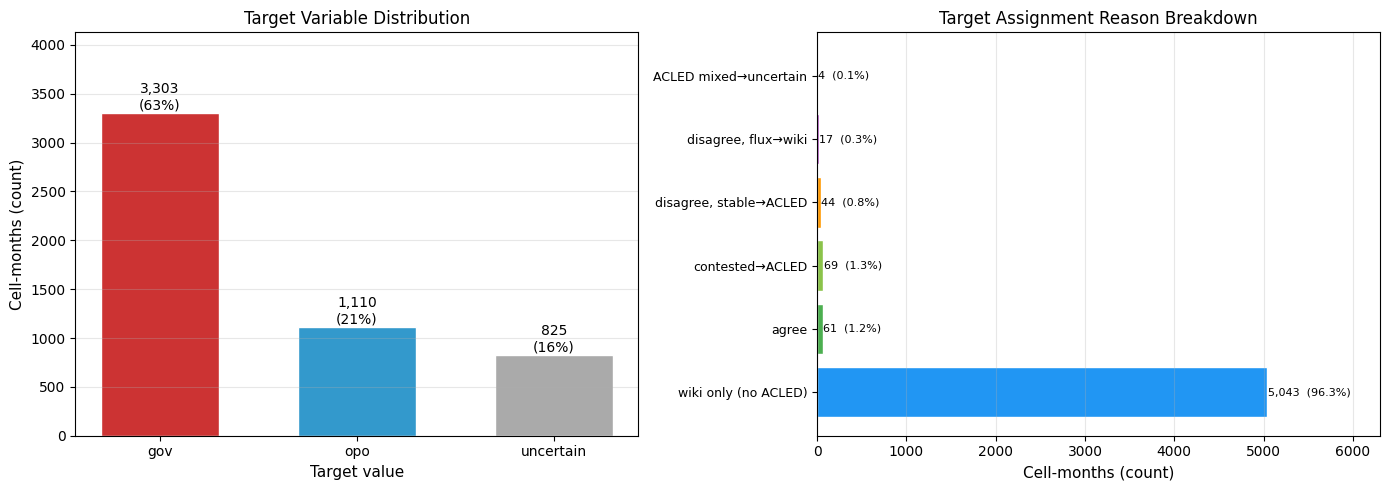

Saved: ../reports/figures/10_target_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: target distribution
ax = axes[0]
tgt_counts = target_df['target'].value_counts().reindex(['gov', 'opo', 'uncertain'], fill_value=0)
bars = ax.bar(
    tgt_counts.index, tgt_counts.values,
    color=[TARGET_COLORS[k] for k in tgt_counts.index],
    edgecolor='white', width=0.6
)
for bar, val in zip(bars, tgt_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}\n({100*val/N:.0f}%)', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Target value', fontsize=11)
ax.set_ylabel('Cell-months (count)', fontsize=11)
ax.set_title('Target Variable Distribution', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, tgt_counts.max() * 1.25)

# Right: reason breakdown
ax = axes[1]
reason_counts = target_df['reason'].value_counts().reindex(reason_order, fill_value=0)
short_labels = {
    'wiki_only':                      'wiki only (no ACLED)',
    'agree':                          'agree',
    'wiki_contested_use_acled':       'contested→ACLED',
    'disagree_stable_wiki_use_acled': 'disagree, stable→ACLED',
    'disagree_recent_wiki_use_wiki':  'disagree, flux→wiki',
    'acled_mixed':                    'ACLED mixed→uncertain',
}
y_pos = range(len(reason_order))
ax.barh(
    list(y_pos), reason_counts.values,
    color=[REASON_COLORS[r] for r in reason_order],
    edgecolor='white'
)
ax.set_yticks(list(y_pos))
ax.set_yticklabels([short_labels[r] for r in reason_order], fontsize=9)
for i, (r, v) in enumerate(zip(reason_order, reason_counts.values)):
    ax.text(v + 5, i, f'{v:,}  ({100*v/N:.1f}%)', va='center', fontsize=8)
ax.set_xlabel('Cell-months (count)', fontsize=11)
ax.set_title('Target Assignment Reason Breakdown', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, reason_counts.max() * 1.25)

plt.tight_layout()
plt.savefig(FIG / '10_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG / "10_target_distribution.png"}')

## 10. Time series: target composition and uncertain rate per month

Top 10 months by uncertain rate:
  2023-11  rate=0.331  n_unc=54/163  █████████
  2023-12  rate=0.329  n_unc=54/164  █████████
  2024-01  rate=0.321  n_unc=53/165  █████████
  2024-02  rate=0.285  n_unc=47/165  ████████
  2024-04  rate=0.246  n_unc=43/175  ███████
  2024-06  rate=0.244  n_unc=44/180  ███████
  2024-07  rate=0.230  n_unc=42/183  ██████
  2024-03  rate=0.229  n_unc=39/170  ██████
  2024-05  rate=0.220  n_unc=39/177  ██████
  2024-09  rate=0.130  n_unc=24/184  ███


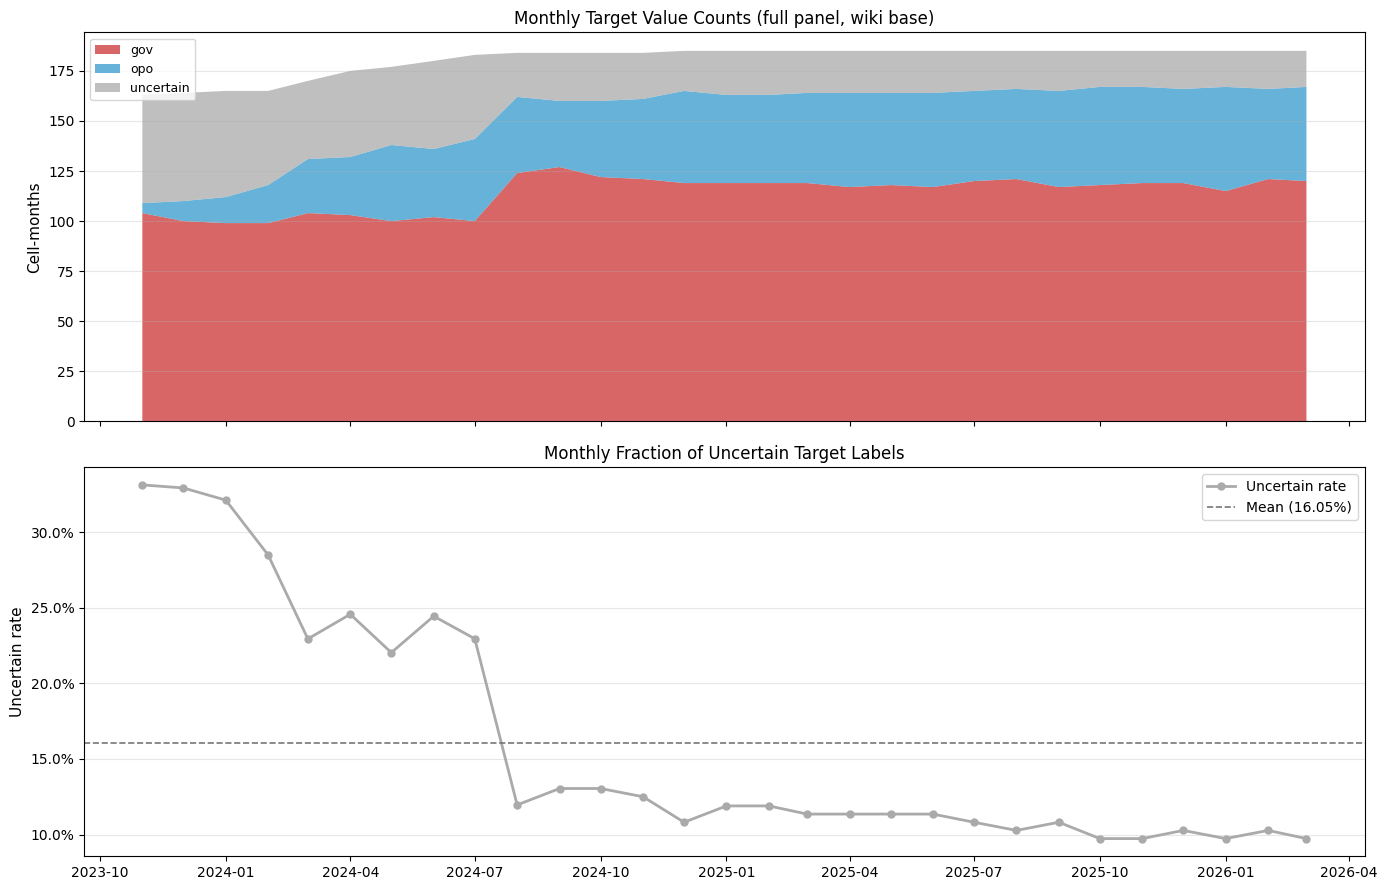

Saved: ../reports/figures/10_uncertain_rate_timeseries.png


In [12]:
monthly = (
    target_df
    .groupby('year_month')
    .agg(
        n_total     = ('target', 'count'),
        n_gov       = ('target', lambda x: (x == 'gov').sum()),
        n_opo       = ('target', lambda x: (x == 'opo').sum()),
        n_uncertain = ('target', lambda x: (x == 'uncertain').sum()),
    )
    .reset_index()
)
monthly['ym_dt']          = pd.to_datetime(monthly['year_month'] + '-01')
monthly['uncertain_rate'] = monthly['n_uncertain'] / monthly['n_total'].clip(lower=1)

print('Top 10 months by uncertain rate:')
top = monthly.sort_values('uncertain_rate', ascending=False).head(10)
for _, r in top.iterrows():
    bar = '█' * int(r['uncertain_rate'] * 30)
    print(f'  {r["year_month"]}  rate={r["uncertain_rate"]:.3f}  '
          f'n_unc={int(r["n_uncertain"]):>2}/{int(r["n_total"]):>3}  {bar}')

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.stackplot(
    monthly['ym_dt'],
    monthly['n_gov'],
    monthly['n_opo'],
    monthly['n_uncertain'],
    labels=['gov', 'opo', 'uncertain'],
    colors=[TARGET_COLORS['gov'], TARGET_COLORS['opo'], TARGET_COLORS['uncertain']],
    alpha=0.75
)
ax.set_ylabel('Cell-months', fontsize=11)
ax.set_title('Monthly Target Value Counts (full panel, wiki base)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.plot(monthly['ym_dt'], monthly['uncertain_rate'] * 100,
        '-o', color=TARGET_COLORS['uncertain'], ms=5, lw=2, label='Uncertain rate')
mean_unc = monthly['uncertain_rate'].mean() * 100
ax.axhline(mean_unc, ls='--', color='#777', lw=1.2, label=f'Mean ({mean_unc:.2f}%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Uncertain rate', fontsize=11)
ax.set_title('Monthly Fraction of Uncertain Target Labels', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / '10_uncertain_rate_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG / "10_uncertain_rate_timeseries.png"}')

## 11. Spatial map: dominant target and uncertain rate per cell

Cells in panel: 185
Cells with ≥1 uncertain month: 69
Dominant target distribution:
dominant_tgt
gov          120
opo           45
uncertain     20


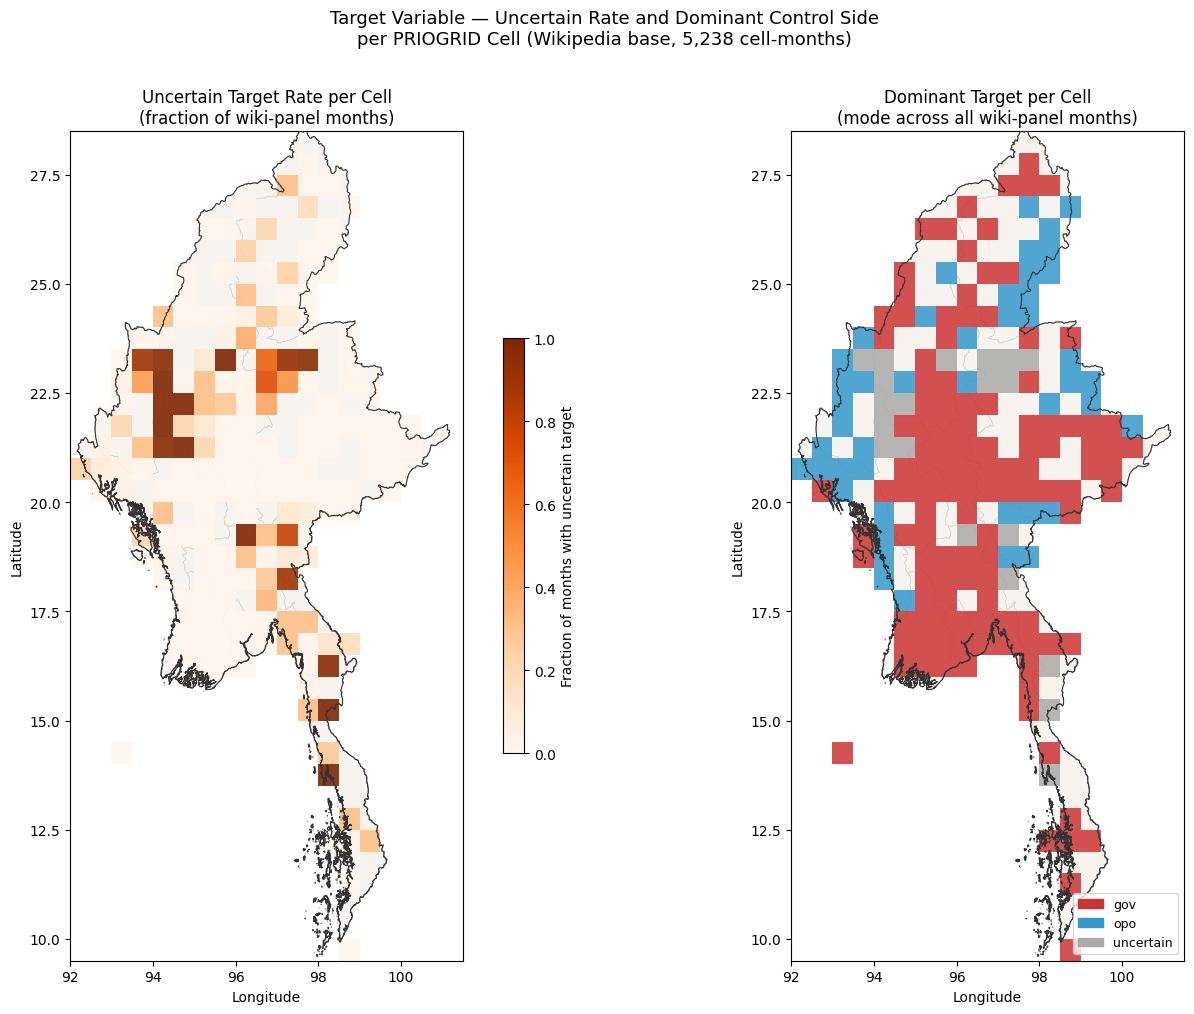

Saved: ../reports/figures/10_uncertain_cells_map.png


In [13]:
gadm1 = gpd.read_file(GADM_PATH, layer='ADM_ADM_1').to_crs('EPSG:4326')
gadm0 = gpd.read_file(GADM_PATH, layer='ADM_ADM_0').to_crs('EPSG:4326')

cell_stats = (
    target_df
    .groupby('priogrid_gid')
    .agg(
        n_months      = ('year_month',  'nunique'),
        n_gov         = ('target', lambda x: (x == 'gov').sum()),
        n_opo         = ('target', lambda x: (x == 'opo').sum()),
        n_uncertain   = ('target', lambda x: (x == 'uncertain').sum()),
        dominant_tgt  = ('target', lambda x: x.mode().iloc[0]),
    )
    .reset_index()
)
cell_stats['uncertain_rate'] = cell_stats['n_uncertain'] / cell_stats['n_months'].clip(lower=1)

print(f'Cells in panel: {len(cell_stats)}')
print(f'Cells with ≥1 uncertain month: {(cell_stats["n_uncertain"] > 0).sum()}')
print(f'Dominant target distribution:')
print(cell_stats['dominant_tgt'].value_counts().to_string())

cells_gdf = gpd.GeoDataFrame(
    cell_stats,
    geometry=[gid_to_geometry(g) for g in cell_stats['priogrid_gid']],
    crs='EPSG:4326'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

ax = axes[0]
gadm1.plot(ax=ax, color='#f7f4ef', edgecolor='#ccc', linewidth=0.4, zorder=1)
cells_gdf.plot(
    column='uncertain_rate', ax=ax, cmap='Oranges',
    vmin=0, vmax=1, edgecolor='none', alpha=0.9, zorder=2,
    legend=True,
    legend_kwds={'label': 'Fraction of months with uncertain target', 'shrink': 0.5}
)
gadm0.boundary.plot(ax=ax, color='#333', linewidth=0.8, zorder=3)
ax.set_xlim(*MMR[::2]); ax.set_ylim(*MMR[1::2])
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Uncertain Target Rate per Cell\n(fraction of wiki-panel months)', fontsize=12)

ax = axes[1]
gadm1.plot(ax=ax, color='#f7f4ef', edgecolor='#ccc', linewidth=0.4, zorder=1)
for tgt_val, color in TARGET_COLORS.items():
    sub = cells_gdf[cells_gdf['dominant_tgt'] == tgt_val]
    if len(sub) > 0:
        sub.plot(ax=ax, color=color, edgecolor='none', alpha=0.85, zorder=2, label=tgt_val)
gadm0.boundary.plot(ax=ax, color='#333', linewidth=0.8, zorder=3)
ax.set_xlim(*MMR[::2]); ax.set_ylim(*MMR[1::2])
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Dominant Target per Cell\n(mode across all wiki-panel months)', fontsize=12)
legend_patches = [mpatches.Patch(color=c, label=k) for k, c in TARGET_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.suptitle('Target Variable — Uncertain Rate and Dominant Control Side\n'
             'per PRIOGRID Cell (Wikipedia base, 5,238 cell-months)', fontsize=13, y=1.01)
plt.tight_layout()
FIG_MAP = FIG / '10_uncertain_cells_map.png'
plt.savefig(FIG_MAP, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_MAP}')

## 12. Final summary block

In [14]:
N   = len(target_df)
p   = lambda x: 100 * x / N
tgt = {v: (target_df['target'] == v).sum() for v in ['gov', 'opo', 'uncertain']}
rsn = {r: (target_df['reason'] == r).sum() for r in reason_order}

print('=' * 65)
print('TARGET VARIABLE BUILT')
print('=' * 65)
print(f'Base:  Wikipedia panel — {N:,} cell-months  |  '
      f'{target_df["priogrid_gid"].nunique()} cells  |  '
      f'{target_df["year_month"].nunique()} months')
print(f'Range: {target_df["year_month"].min()} → {target_df["year_month"].max()}')
print()
print('Target distribution:')
print(f'  gov:       {tgt["gov"]:>5,}  ({p(tgt["gov"]):5.1f}%)')
print(f'  opo:       {tgt["opo"]:>5,}  ({p(tgt["opo"]):5.1f}%)')
print(f'  uncertain: {tgt["uncertain"]:>5,}  ({p(tgt["uncertain"]):5.1f}%)')
print()
print('Reason breakdown:')
for r in reason_order:
    print(f'  {r:<35} {rsn[r]:>5,}  ({p(rsn[r]):5.1f}%)')
print()
n_acled = (target_df['agreement'] != 'wiki_only').sum()
print(f'Source breakdown:')
print(f'  Wiki only (no ACLED ctrl signal): {N - n_acled:>5,}  ({p(N-n_acled):5.1f}%)')
print(f'  Wiki + ACLED ctrl signal:         {n_acled:>5,}  ({p(n_acled):5.1f}%)')
print()
print('Outputs:')
for path in [
    CKPT_OUT,
    FIG / '10_target_distribution.png',
    FIG / '10_uncertain_rate_timeseries.png',
    FIG / '10_uncertain_cells_map.png',
]:
    size = path.stat().st_size / 1e3 if path.exists() else 0
    print(f'  {path.name:<52}  {size:6.0f} KB')
print('=' * 65)

TARGET VARIABLE BUILT
Base:  Wikipedia panel — 5,238 cell-months  |  185 cells  |  29 months
Range: 2023-11 → 2026-03

Target distribution:
  gov:       3,303  ( 63.1%)
  opo:       1,110  ( 21.2%)
  uncertain:   825  ( 15.8%)

Reason breakdown:
  wiki_only                           5,043  ( 96.3%)
  agree                                  61  (  1.2%)
  wiki_contested_use_acled               69  (  1.3%)
  disagree_stable_wiki_use_acled         44  (  0.8%)
  disagree_recent_wiki_use_wiki          17  (  0.3%)
  acled_mixed                             4  (  0.1%)

Source breakdown:
  Wiki only (no ACLED ctrl signal): 5,043  ( 96.3%)
  Wiki + ACLED ctrl signal:           195  (  3.7%)

Outputs:
  10_target_variable.parquet                                15 KB
  10_target_distribution.png                                85 KB
  10_uncertain_rate_timeseries.png                         104 KB
  10_uncertain_cells_map.png                               308 KB
